# TP10 — Normalisation intra-machine

GroupKFold (TP9) a révélé une variance inter-machines de ±0.1772.  
Le modèle mémorise les baselines absolues de chaque machine.  
On applique un **z-score par machine** pour que le modèle apprenne des écarts plutôt que des niveaux.

| Modèle | PR-AUC CV | PR-AUC test | Δ std |
|--------|-----------|-------------|-------|
| B9-GKF (TP9, sans normalisation) | 0.7792 ± 0.1772 | 0.8595 | — |
| **B10-NRM** | ? | ? | ? |

## 1. Imports

In [9]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Imports OK")

Imports OK


## 2. Données

In [10]:
url = URL.create(
    drivername="postgresql+psycopg2",
    username="indusense_user",
    password="ThEP@ssW0rd",
    host="localhost", port=5432, database="indusense_db",
)
engine = create_engine(url)
df = pd.read_sql(
    "SELECT * FROM gold_machine_hourly_feature ORDER BY machine_id, window_start",
    engine
)

TARGET = "label_failure_next_24h"
LEAKAGE_COLS = [
    "machine_id", "ingestion_batch_id", "window_start", "window_end", "split_set",
    "label_failure_next_6h", "label_failure_next_12h", "label_failure_next_48h",
    TARGET, "feature_row_id",
]
# Features déjà normalisées par machine → exclure pour éviter double normalisation
ALREADY_NORMALIZED = [c for c in df.columns if "zscore_machine" in c]
FEATURE_COLS = [c for c in df.columns if c not in LEAKAGE_COLS and c not in ALREADY_NORMALIZED]

trainval_df = df[df["split_set"].isin(["train", "validation"])].copy()
test_df     = df[df["split_set"] == "test"].copy()

X_tv   = trainval_df[FEATURE_COLS]
y_tv   = trainval_df[TARGET]
groups = trainval_df["machine_id"]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET]

N_MACHINES = groups.nunique()
print(f"Features : {len(FEATURE_COLS)} (dont {len(ALREADY_NORMALIZED)} zscore_machine exclus)")
print(f"Machines : {N_MACHINES} | Train+val : {len(X_tv):,} | Test : {len(X_test):,}")

Features : 67 (dont 2 zscore_machine exclus)
Machines : 15 | Train+val : 112,996 | Test : 19,944


## 3. Fonction de normalisation intra-machine

Les stats (µ, σ) sont calculées sur le **train du fold uniquement** pour éviter la fuite.  
Pour la machine val (absente du train), on utilise les stats de la flotte comme fallback.

In [11]:
def normalize_by_machine(df_train_ref, df_to_transform, feature_cols):
    """
    Calcule µ/σ par machine sur df_train_ref, applique à df_to_transform.
    Les deux DataFrames doivent avoir une colonne 'machine_id'.
    Fallback flotte pour les machines absentes du train.
    """
    stats     = df_train_ref.groupby("machine_id")[feature_cols].agg(["mean", "std"])
    fleet_mu  = df_train_ref[feature_cols].apply(pd.to_numeric, errors="coerce").mean()
    fleet_sig = df_train_ref[feature_cols].apply(pd.to_numeric, errors="coerce").std().replace(0, 1)

    result = df_to_transform[feature_cols].apply(pd.to_numeric, errors="coerce").copy()
    m_ids  = df_to_transform["machine_id"].reset_index(drop=True)

    for col in feature_cols:
        mu  = m_ids.map(stats[col]["mean"]).fillna(fleet_mu[col]).astype(float)
        sig = m_ids.map(stats[col]["std"]).fillna(fleet_sig[col]).replace(0, 1).astype(float)
        result[col] = (result[col].astype(float).values - mu.values) / sig.values

    return result

print("normalize_by_machine définie")

normalize_by_machine définie


## 4. GroupKFold CV — B10-NRM

Même hyperparamètres B8, même validation GroupKFold que TP9,  
mais chaque fold normalise ses features par machine avant l'entraînement.

In [12]:
B8_PARAMS = {
    "max_depth":        8,
    "learning_rate":    0.19367782999811112,
    "n_estimators":     382,
    "subsample":        0.9870283480802571,
    "colsample_bytree": 0.8035421212629575,
    "min_child_weight": 6,
    "reg_alpha":        0.0014393622771964793,
    "reg_lambda":       0.00014158997638181163,
    "random_state":     RANDOM_STATE,
    "verbosity":        0,
}

tv_with_id = trainval_df[["machine_id"] + FEATURE_COLS + [TARGET]].copy().reset_index(drop=True)

gkf = GroupKFold(n_splits=N_MACHINES)
fold_results = []

for fold_i, (tr_idx, vl_idx) in enumerate(gkf.split(tv_with_id, y_tv, groups)):
    machine_val = groups.iloc[vl_idx].unique()[0]

    df_tr = tv_with_id.iloc[tr_idx].reset_index(drop=True)
    df_vl = tv_with_id.iloc[vl_idx].reset_index(drop=True)
    y_tr  = y_tv.iloc[tr_idx].values
    y_vl  = y_tv.iloc[vl_idx].values

    X_tr_norm = normalize_by_machine(df_tr, df_tr, FEATURE_COLS)
    X_vl_norm = normalize_by_machine(df_tr, df_vl, FEATURE_COLS)

    spw = round((y_tr == 0).sum() / max((y_tr == 1).sum(), 1), 2)
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   XGBClassifier(**{**B8_PARAMS, "scale_pos_weight": spw})),
    ])
    pipe.fit(X_tr_norm, y_tr)

    y_prob = pipe.predict_proba(X_vl_norm)[:, 1]
    n_pos  = int(y_vl.sum())
    pr_auc = average_precision_score(y_vl, y_prob) if n_pos >= 2 else float("nan")

    fold_results.append({"fold": fold_i+1, "machine": machine_val,
                         "n_pos": n_pos, "pr_auc": round(pr_auc, 4)})
    print(f"Fold {fold_i+1:2d} | {machine_val:<10} | n_pos={n_pos:4d} | PR-AUC={pr_auc:.4f}")

results_df = pd.DataFrame(fold_results)
valid = results_df.dropna(subset=["pr_auc"])
print(f"\nPR-AUC CV moyen : {valid['pr_auc'].mean():.4f} ± {valid['pr_auc'].std():.4f}")
print(f"Min : {valid['pr_auc'].min():.4f} | Max : {valid['pr_auc'].max():.4f}")

Fold  1 | MACH-15    | n_pos=  71 | PR-AUC=0.5840
Fold  2 | MACH-01    | n_pos= 491 | PR-AUC=0.9274
Fold  3 | MACH-12    | n_pos= 213 | PR-AUC=0.5122
Fold  4 | MACH-07    | n_pos=  71 | PR-AUC=0.1503
Fold  5 | MACH-05    | n_pos= 189 | PR-AUC=0.3015
Fold  6 | MACH-11    | n_pos=  48 | PR-AUC=0.8720
Fold  7 | MACH-10    | n_pos= 292 | PR-AUC=0.4927
Fold  8 | MACH-14    | n_pos= 314 | PR-AUC=0.4627
Fold  9 | MACH-13    | n_pos= 809 | PR-AUC=0.7023
Fold 10 | MACH-04    | n_pos= 190 | PR-AUC=0.5367
Fold 11 | MACH-02    | n_pos=  72 | PR-AUC=0.3356
Fold 12 | MACH-06    | n_pos= 338 | PR-AUC=0.4340
Fold 13 | MACH-08    | n_pos=  48 | PR-AUC=0.9208
Fold 14 | MACH-03    | n_pos= 632 | PR-AUC=0.4553
Fold 15 | MACH-09    | n_pos= 240 | PR-AUC=0.6826

PR-AUC CV moyen : 0.5580 ± 0.2279
Min : 0.1503 | Max : 0.9274


## 5. Comparaison B9-GKF vs B10-NRM par machine

Machine        B9-GKF   B10-NRM        Δ
------------------------------------------
MACH-07         0.329     0.150  -0.179 ↓
MACH-05         0.568     0.301  -0.266 ↓
MACH-13         0.639     0.702  +0.063 ↑
MACH-02         0.664     0.336  -0.328 ↓
MACH-03         0.707     0.455  -0.252 ↓
MACH-10         0.760     0.493  -0.267 ↓
MACH-12         0.761     0.512  -0.249 ↓
MACH-09         0.784     0.683  -0.101 ↓
MACH-14         0.793     0.463  -0.330 ↓
MACH-04         0.874     0.537  -0.337 ↓
MACH-01         0.878     0.927  +0.049 ↑
MACH-06         0.917     0.434  -0.483 ↓
MACH-08         0.955     0.921  -0.034 ↓
MACH-15         1.000     0.584  -0.416 ↓
MACH-11         1.000     0.872  -0.128 ↓

Moyenne  B9=0.7753  B10=0.5580  Δ=-0.2173
Std      B9=0.1772               B10=0.2279  Δ=+0.0507


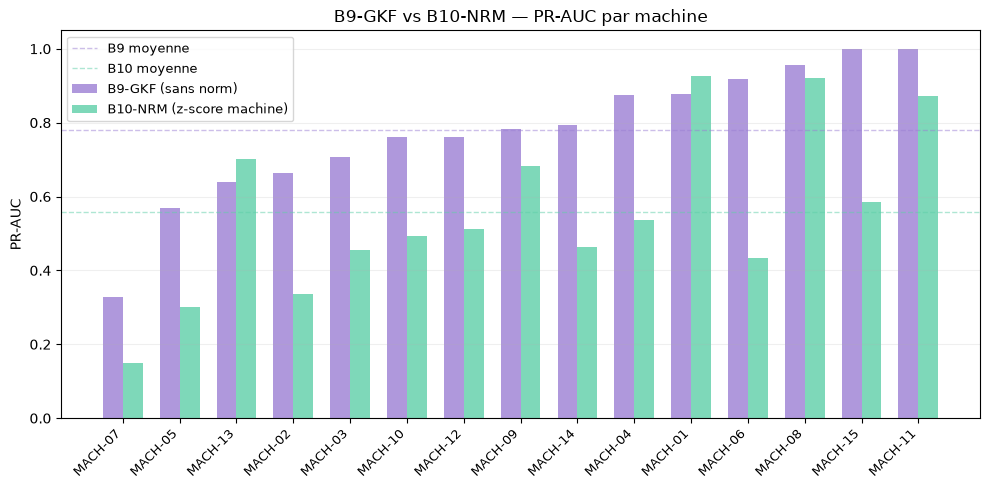

In [13]:
# Scores TP9 pour comparaison
B9_SCORES = {
    "MACH-07": 0.329, "MACH-05": 0.568, "MACH-13": 0.639, "MACH-02": 0.664,
    "MACH-03": 0.707, "MACH-10": 0.760, "MACH-12": 0.761, "MACH-09": 0.784,
    "MACH-14": 0.793, "MACH-04": 0.874, "MACH-01": 0.878, "MACH-06": 0.917,
    "MACH-08": 0.955, "MACH-15": 1.000, "MACH-11": 1.000,
}

comp = valid.copy()
comp["b9"]   = comp["machine"].map(B9_SCORES)
comp["delta"] = comp["pr_auc"] - comp["b9"]
comp_sorted = comp.sort_values("b9")

print(f"{'Machine':<12} {'B9-GKF':>8} {'B10-NRM':>9} {'Δ':>8}")
print("-" * 42)
for _, row in comp_sorted.iterrows():
    arrow = "↑" if row["delta"] > 0.01 else "↓" if row["delta"] < -0.01 else "≈"
    print(f"{row['machine']:<12} {row['b9']:>8.3f} {row['pr_auc']:>9.3f} {row['delta']:>+7.3f} {arrow}")

print(f"\nMoyenne  B9={sum(B9_SCORES.values())/len(B9_SCORES):.4f}  B10={valid['pr_auc'].mean():.4f}  Δ={valid['pr_auc'].mean()-sum(B9_SCORES.values())/len(B9_SCORES):+.4f}")
print(f"Std      B9=0.1772               B10={valid['pr_auc'].std():.4f}  Δ={valid['pr_auc'].std()-0.1772:+.4f}")

# Graphique comparatif
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(comp_sorted))
w = 0.35
ax.bar(x - w/2, comp_sorted["b9"],      w, label="B9-GKF (sans norm)", color="#9B7FD4", alpha=0.8)
ax.bar(x + w/2, comp_sorted["pr_auc"],  w, label="B10-NRM (z-score machine)", color="#5ECFA8", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(comp_sorted["machine"], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("PR-AUC")
ax.set_title("B9-GKF vs B10-NRM — PR-AUC par machine")
ax.axhline(0.7792, color="#9B7FD4", linestyle="--", linewidth=1, alpha=0.5, label="B9 moyenne")
ax.axhline(valid["pr_auc"].mean(), color="#5ECFA8", linestyle="--", linewidth=1, alpha=0.5, label="B10 moyenne")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.savefig("b10_comparison.png", dpi=150)
plt.show()

## 6. Modèle final — entraîné sur tout train+val, évalué sur test

In [14]:
test_with_id = test_df[["machine_id"] + FEATURE_COLS].copy().reset_index(drop=True)

X_tv_norm   = normalize_by_machine(tv_with_id, tv_with_id,   FEATURE_COLS)
X_test_norm = normalize_by_machine(tv_with_id, test_with_id, FEATURE_COLS)

SPW_FULL = round((y_tv == 0).sum() / (y_tv == 1).sum(), 2)
pipe_final = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBClassifier(**{**B8_PARAMS, "scale_pos_weight": SPW_FULL})),
])
pipe_final.fit(X_tv_norm, y_tv)

pr_train = average_precision_score(y_tv,   pipe_final.predict_proba(X_tv_norm)[:, 1])
pr_test  = average_precision_score(y_test, pipe_final.predict_proba(X_test_norm)[:, 1])
roc_test = roc_auc_score(y_test,           pipe_final.predict_proba(X_test_norm)[:, 1])
f1_test  = f1_score(y_test,                pipe_final.predict(X_test_norm), zero_division=0)

print("=== Modèle final B10-NRM ===")
print(f"  PR-AUC train    : {pr_train:.4f}")
print(f"  PR-AUC CV moyen : {valid['pr_auc'].mean():.4f} ± {valid['pr_auc'].std():.4f}")
print(f"  PR-AUC test     : {pr_test:.4f}")
print(f"  ROC-AUC test    : {roc_test:.4f}")
print(f"  F1 test         : {f1_test:.4f}")

print("\n=== Comparaison globale ===")
print(f"  {'Modèle':<14} {'PR-AUC CV':>12} {'PR-AUC test':>13} {'F1 test':>10}")
print("  " + "-"*53)
print(f"  {'B9-GKF':<14} {'0.7792±0.177':>12} {'0.8595':>13} {'0.7908':>10}")
print(f"  {'B10-NRM':<14} {str(round(valid['pr_auc'].mean(),4))+'±'+str(round(valid['pr_auc'].std(),4)):>12} {pr_test:>13.4f} {f1_test:>10.4f}")

=== Modèle final B10-NRM ===
  PR-AUC train    : 1.0000
  PR-AUC CV moyen : 0.5580 ± 0.2279
  PR-AUC test     : 0.7707
  ROC-AUC test    : 0.9912
  F1 test         : 0.7065

=== Comparaison globale ===
  Modèle            PR-AUC CV   PR-AUC test    F1 test
  -----------------------------------------------------
  B9-GKF         0.7792±0.177        0.8595     0.7908
  B10-NRM        0.558±0.2279        0.7707     0.7065
